# Can we predict cell types from factor scores?

### Load packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path
import mofaflex as mfl
import scanpy as sc

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Load model

In [27]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [77]:
model_sns = mfl.MOFAFLEX.load(models_path / "sns_models/crc_231_no_mye/Normal.SnS/crc_231_no_mye.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


In [ ]:
#model_nor = mfl.MOFAFLEX.load(models_path / "crc_231.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_231_no_mye/GP.Normal/crc_231_no_mye.GP.Normal.hdf5")

In [78]:
factors = model_sns.get_factors()

In [79]:
F = factors["group_1"]

In [ ]:
cell_names = F.index

### Load lrdata object

In [36]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_231_lrdata.h5ad")

In [81]:
cell_types = lrdata.obs["typ"]

In [82]:
cell_types = cell_types.sort_index()

In [83]:
F=  F.sort_index()

In [84]:
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [85]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_100_100,-2.390690,-0.117418,-1.428030,-0.398287,-1.225173,-4.096662,-2.190624,0.259481,-0.757814,1.290376,3.237960,-1.146409,2.205097,0.456879,2.278627
c_3_100_1002,-2.604829,-0.249317,0.317681,1.031869,0.148582,-1.018346,-2.582053,-2.088721,-1.796446,-0.396183,-1.559294,0.259003,-0.618557,-0.617940,-0.721687
c_3_100_1008,-0.930688,2.812917,-0.023195,-0.318480,-1.257216,-0.747722,1.257658,0.028744,0.856988,-0.830670,-0.066359,-0.774942,-0.582422,-0.269103,-0.397005
c_3_100_1044,-0.084350,-0.740045,-0.950441,0.559322,0.285300,0.429939,-0.929555,0.348640,-0.474703,-0.797144,1.035168,0.516352,0.346799,-0.096072,-0.207164
c_3_100_1105,0.191362,-0.631614,4.167848,0.657468,2.408977,0.939129,2.421700,1.087685,1.499850,1.770883,-0.002101,-0.463288,0.845474,-2.760019,4.081117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_9_96,0.312126,-0.007951,-0.982569,-0.541152,1.108116,-0.864438,1.315650,-1.662369,0.800986,-1.194793,-1.383410,0.756995,0.230581,-0.330423,0.238110
c_3_9_967,0.553478,-1.088417,-0.076083,-0.808770,0.400545,-0.226704,0.109568,0.106078,0.216751,-0.606037,0.739728,0.146426,-0.623585,-0.074366,-0.890017
c_3_9_97,-0.887609,-0.904385,0.045062,1.429103,-1.203557,0.574620,3.001877,-1.348162,0.489598,0.766766,0.812195,2.724646,3.195811,-1.666375,1.093045
c_3_9_978,-0.312804,0.266032,0.202350,0.238238,-0.295396,0.166539,0.487994,-0.030125,-0.027047,-0.641308,-0.323894,-0.356165,0.107007,0.302157,0.082023


In [86]:
filtered_cell_types

c_3_100_100     231_CRC
c_3_100_1002    231_CRC
c_3_100_1008    231_CRC
c_3_100_1044    231_CRC
c_3_100_1105    231_CRC
                 ...   
c_3_9_96        231_CRC
c_3_9_967       231_REF
c_3_9_97        231_CRC
c_3_9_978       231_REF
c_3_9_981       231_REF
Name: typ, Length: 43372, dtype: category
Categories (3, object): ['231_CRC', '231_REF', '231_TVA']

In [87]:
print(F.values)  # feature matrix
print(filtered_cell_types.values)  # labels

[[-2.3906898  -0.11741812 -1.4280304  ...  2.2050972   0.4568788
   2.278627  ]
 [-2.6048288  -0.24931705  0.31768093 ... -0.61855656 -0.6179401
  -0.7216867 ]
 [-0.93068826  2.8129175  -0.02319481 ... -0.58242184 -0.26910296
  -0.39700526]
 ...
 [-0.8876085  -0.9043852   0.04506207 ...  3.1958108  -1.6663748
   1.0930454 ]
 [-0.3128041   0.266032    0.20234987 ...  0.10700657  0.30215722
   0.08202302]
 [-0.26169187 -0.1705782   0.23800844 ... -0.16658136  0.30934036
  -0.13950738]]
['231_CRC', '231_CRC', '231_CRC', '231_CRC', '231_CRC', ..., '231_CRC', '231_REF', '231_CRC', '231_REF', '231_REF']
Length: 43372
Categories (3, object): ['231_CRC', '231_REF', '231_TVA']


In [88]:
X = F.values
y = filtered_cell_types.values  # labels

In [89]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [90]:
print(X.shape, y.shape)

(41257, 15) (41257,)


In [91]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -9.792684
Max: 9.405033
Mean: 0.0062423875
Median: 0.0032885617
Std dev: 0.917171


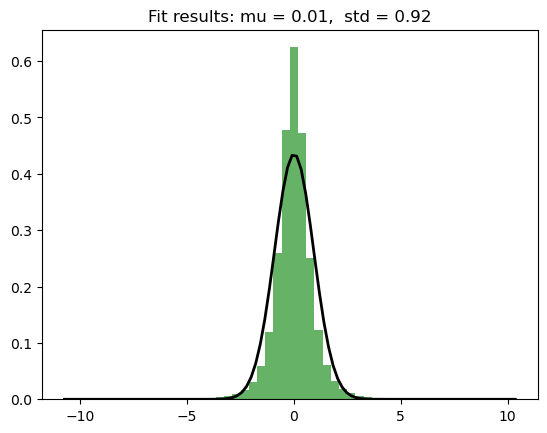

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


## Regression Model

In [93]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Train multinomial logistic regression - Cell types

In [94]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [95]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [96]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.48303441589917595

Classification Report:
               precision    recall  f1-score   support

     231_CRC       0.42      0.52      0.46      2839
     231_REF       0.21      0.55      0.31      1654
     231_TVA       0.78      0.46      0.58      7885

    accuracy                           0.48     12378
   macro avg       0.47      0.51      0.45     12378
weighted avg       0.62      0.48      0.51     12378



In [97]:
from sklearn.metrics import roc_auc_score, roc_curve


In [98]:
# Get class probabilities for all 3 classes
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.6848
Multiclass ROC AUC (OvR, weighted): 0.6835
